Epoch 1/10


235/235 [==============================] - 28s 109ms/step - loss: 0.2088 - accuracy: 0.9377 - val_loss: 2.8777 - val_accuracy: 0.2230
Epoch 2/10
235/235 [==============================] - 25s 105ms/step - loss: 0.0540 - accuracy: 0.9841 - val_loss: 0.3741 - val_accuracy: 0.8788
Epoch 3/10
235/235 [==============================] - 30s 129ms/step - loss: 0.0396 - accuracy: 0.9877 - val_loss: 0.0424 - val_accuracy: 0.9866
Epoch 4/10
235/235 [==============================] - 32s 138ms/step - loss: 0.0295 - accuracy: 0.9909 - val_loss: 0.0421 - val_accuracy: 0.9862
Epoch 5/10
235/235 [==============================] - 30s 127ms/step - loss: 0.0257 - accuracy: 0.9919 - val_loss: 0.0361 - val_accuracy: 0.9889
Epoch 6/10
235/235 [==============================] - 27s 113ms/step - loss: 0.0186 - accuracy: 0.9942 - val_loss: 0.0356 - val_accuracy: 0.9886
Epoch 7/10
235/235 [==============================] - 27s 113ms/step - loss: 0.0161 - accuracy: 0.9950 - val_loss: 0.0320 - val_

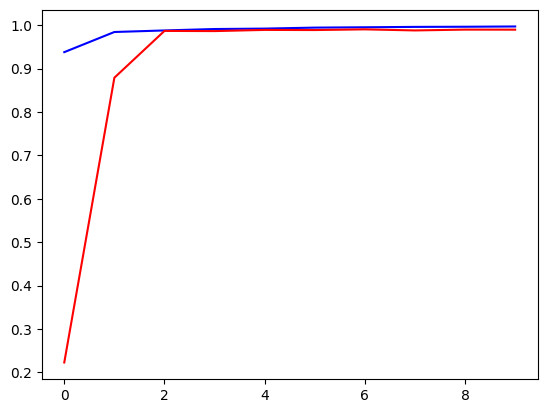

In [4]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist
import matplotlib.pyplot as plt 

(x_train, y_train),(x_test,y_test) = mnist.load_data()
x_train = x_train.reshape((-1,28,28,1)).astype('float32') / 255
x_test = x_test.reshape((-1,28,28,1)).astype('float32') / 255

# On doit spécifier input_shape seulement pour la première couche
# Elle doit savoir à quoi ressemble l’image d’entrée : largeur, hauteur, canaux (ici 28x28, en niveau de gris donc 1 canal)
model = keras.Sequential()
model.add(keras.layers.Conv2D(32,(3,3),input_shape=(28,28,1)))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.MaxPool2D((2,2)))

# Pas besoin d’input_shape car le modèle sait déjà à quoi ressemble la sortie de la couche précédente
model.add(keras.layers.Conv2D(32,(3,3)))
model.add(keras.layers.BatchNormalization())
model.add(keras.layers.Activation('relu'))
model.add(keras.layers.MaxPool2D((2,2)))

model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(128,activation='relu'))
model.add(keras.layers.Dense(10,activation='softmax'))

model.compile(optimizer=tf.optimizers.Adam(),loss=tf.losses.sparse_categorical_crossentropy, metrics=['accuracy'])

hist = model.fit(x_train, y_train, epochs=10, batch_size=256, validation_data=(x_test,y_test))

plt.plot(hist.history['accuracy'],color= 'blue')
plt.plot(hist.history['val_accuracy'],color='red')
